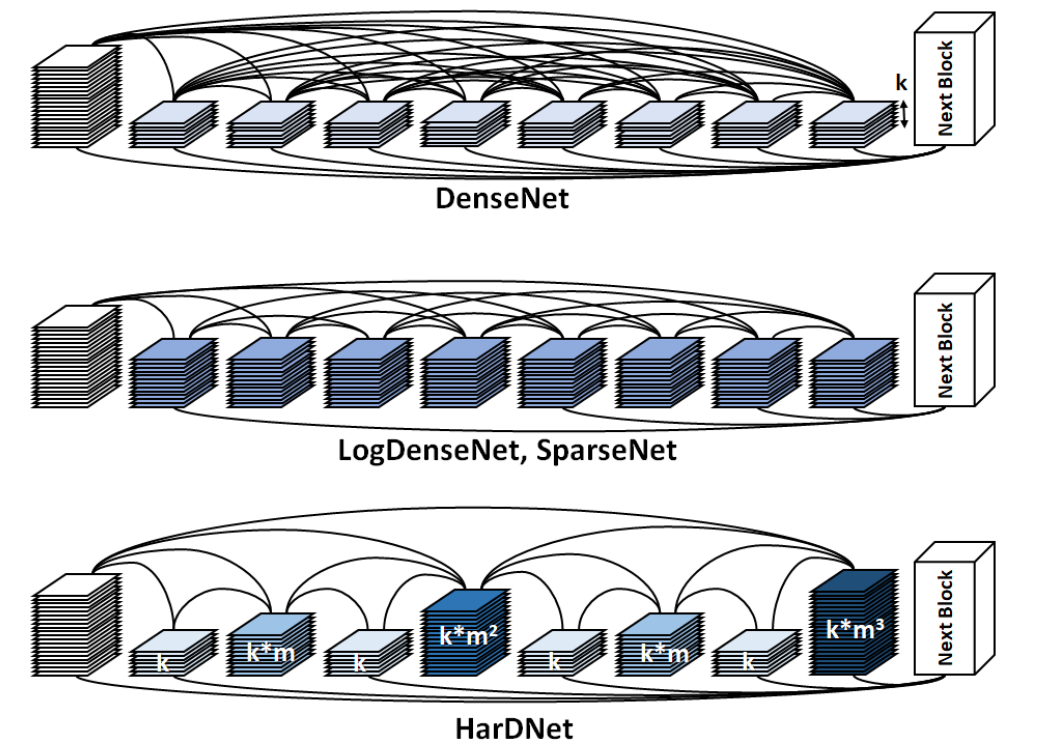

ch_list = [32, 64, 96, 128, 160]  # 每阶段目标通道数
grmul = 1.7                        # 增长率乘数
gr = [10, 16, 18, 24, 32]         # 各HarDBlock的基础增长率
n_layers = [4, 4, 8, 8, 8]        # 各HarDBlock的层数

**encoder**      
stage0：初始下采样    
self.base.append(ConvLayer(in_channels=input_ch, out_channels=32, kernel=3, stride=2))        
输入Cx1024x1024，C通常是192      
输出32x512x512
作用是快速降低分辨率，减少计算量

Stage 1-5: HarDBlock处理         
for i in range(5):
    # 1. HarDBlock - 特征提取
    blk = HarDBlock(ch, gr[i], grmul, n_layers[i])
    
    # 2. 保存跳跃连接（前4个阶段）
    if i < 4:
        self.shortcut_layers.append(len(self.base) - 1)
    
    # 3. 1×1卷积 - 通道数调整
    self.base.append(ConvLayer(ch, ch_list[i], kernel=1))
    
    # 4. 平均池化下采样（前4个阶段）
    if i < 4:
        self.base.append(nn.AvgPool2d(kernel_size=2, stride=2))      
Stage 1:
32×512×512 → HarDBlock(32,10,1.7,4) → 74×512×512 → Conv1×1 → 32×512×512 → AvgPool → 32×256×256
保存: 74×512×512 (skip[0])

Stage 2:
32×256×256 → HarDBlock(32,16,1.7,4) → 118×256×256 → Conv1×1 → 64×256×256 → AvgPool → 64×128×128
保存: 118×256×256 (skip[1])

Stage 3:
64×128×128 → HarDBlock(64,18,1.7,8) → 214×128×128 → Conv1×1 → 96×128×128 → AvgPool → 96×64×64
保存: 214×128×128 (skip[2])

Stage 4:
96×64×64 → HarDBlock(96,24,1.7,8) → 298×64×64 → Conv1×1 → 128×64×64 → AvgPool → 128×32×32
保存: 298×64×64 (skip[3])

Stage 5:
128×32×32 → HarDBlock(128,32,1.7,8) → 426×32×32 → Conv1×1 → 160×32×32
(最深层，不下采样，不保存跳跃连接)

**HarDBlock内部机制：**     
def get_out_ch(self):
    # 只有偶数层和最后一层的输出会被concatenate
    out_channels = 0
    for i in range(n_layers):
        if (i % 2 == 0) or (i == n_layers - 1):
            out_channels += 该层输出通道数       

以 HarDBlock(32,10,1.7,4) 为例：       
层0: 输入32 → 保留用于最终concat
层1: 10通道 → 10×1.7 = 17通道（实际取偶数18）
层2: 18通道 → 保留用于最终concat  
层3: 18×1.7 = 30.6 → 30通道
层4: 30通道 → 保留用于最终concat

最终输出: concat[输入32, 层2的18, 层4的30] = 74通道

**decoder**：      
解码器有4个阶段，对应编码器的前4个阶段：        
for i in range(3, -1, -1):  # 从深到浅 [3,2,1,0]
    # 1. 上采样过渡块
    self.transUpBlocks.append(TransitionUp(prev_channels, prev_channels))
    
    # 2. 跳跃连接后的通道融合
    cur_channels = prev_channels + skip_connection_channels[i]
    
    # 3. 通道减半
    self.conv1x1_up.append(ConvLayer(cur_channels, cur_channels//2, kernel=1))
    
    # 4. HarDBlock处理
    blk = HarDBlock(cur_channels//2, gr[i], grmul, n_layers[i])
    self.denseBlocksUp.append(blk)        
Decoder Stage 3 (对应Encoder Stage 4):
160×32×32 → Up×2 → 160×64×64 → Cat(skip[3]:298×64×64) → 458×64×64 → Conv1×1 → 229×64×64 
→ HarDBlock(229,24,1.7,8) → 298×64×64

Decoder Stage 2 (对应Encoder Stage 3):
298×64×64 → Up×2 → 298×128×128 → Cat(skip[2]:214×128×128) → 512×128×128 → Conv1×1 → 256×128×128
→ HarDBlock(256,18,1.7,8) → 214×128×128

Decoder Stage 1 (对应Encoder Stage 2):
214×128×128 → Up×2 → 214×256×256 → Cat(skip[1]:118×256×256) → 332×256×256 → Conv1×1 → 166×256×256
→ HarDBlock(166,16,1.7,4) → 118×256×256

Decoder Stage 0 (对应Encoder Stage 1):
118×256×256 → Up×2 → 118×512×512 → Cat(skip[0]:74×512×512) → 192×512×512 → Conv1×1 → 96×512×512
→ HarDBlock(96,10,1.7,4) → 74×512×512       


**最终输出**    
# 1. 最终上采样恢复原始分辨率
self.final_upsample = nn.ConvTranspose2d(74, 74, kernel=3, stride=2, padding=1)
74×512×512 → 74×1024×1024

# 2. 全局跳跃连接（与原始输入拼接）
out = torch.cat([inputs, out], dim=1)
Cat([原始输入C×1024×1024, 74×1024×1024]) → (C+74)×1024×1024

# 3. 最终分类层
self.finalConv = nn.Conv2d(C+74, num_classes, kernel=1)
(C+74)×1024×1024 → num_classes×1024×1024

1.HarDBlock 层内跳跃（编码器和解码器都有）

作用：特征重用，减少参数，提高效率


2.编码器→解码器跳跃（U-Net 风格）

作用：恢复空间细节，多尺度特征融合


3.全局跳跃（输入→输出）

作用：保留原始特征，帮助精细分割

**se注意力**        
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block"""
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)       
平均池化 -> relu -> 线性层 -> sigmoid -> 权重        
学习到了每个通道的权重，每个通道一个权重，维度：[C, 1, 1]

**cbam注意力**       
class CBAM(nn.Module):
    """Convolutional Block Attention Module"""
    def __init__(self, channel, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        # Channel attention
        self.channel_attention = ChannelAttention(channel, reduction)
        # Spatial attention
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


class ChannelAttention(nn.Module):
    def __init__(self, in_planes, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // reduction, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return x * self.sigmoid(out)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg_out, max_out], dim=1)
        x_cat = self.conv1(x_cat)
        return x * self.sigmoid(x_cat)
cbam分为了通道注意力和空间注意力，先使用通道注意力然后再使用空间注意力       
在se中使用的平均池化，而在cbam中使用的都是平均池化结果和最大池化结果相加的方式      
**为什么是avg+max**：avg：稳定但是可能会忽略重要细节；max能捕捉到显著特征但是可能对噪声敏感；组合起来就是稳定又不会丢失重要信息    
先通道注意力再空间注意力：没有什么理论依据，就是发现这样效果好

**transfomer**       
